In [1]:
# Core libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statistics

# Modeling / stats
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm

# Plot style
sns.set_style('whitegrid')

# Create output folder for figures
os.makedirs('output/figures', exist_ok=True)

In [2]:
# Load the full NBA combine dataset
nba_combine_df = pd.read_csv('nba_draft_combine_all_years.csv')

# Preview the dataset
nba_combine_df.head()

,index,Unnamed: 0,Player,Year,Draft pick,Height (No Shoes),Height (With Shoes),Wingspan,Standing reach,Vertical (Max),Vertical (Max Reach),Vertical (No Step),Vertical (No Step Reach),Weight,Body Fat,Hand (Length),Hand (Width),Bench,Agility,Sprint
0,0,0,Blake Griffin,2009,1.0,80.50,82.00,83.25,105.0,35.5,140.5,32.0,137.0,248.0,8.2,NaN,NaN,22.0,10.95,3.28
1,1,1,Terrence Williams,2009,11.0,77.00,78.25,81.00,103.5,37.0,140.5,30.5,134.0,213.0,5.1,NaN,NaN,9.0,11.15,3.18
2,2,2,Gerald Henderson,2009,12.0,76.00,77.00,82.25,102.5,35.0,137.5,31.5,134.0,215.0,4.4,NaN,NaN,8.0,11.17,3.14
3,3,3,Tyler Hansbrough,2009,13.0,80.25,81.50,83.50,106.0,34.0,140.0,27.5,133.5,234.0,8.5,NaN,NaN,18.0,11.12,3.27
4,4,4,Earl Clark,2009,14.0,80.50,82.25,86.50,109.5,33.0,142.5,28.5,138.0,228.0,5.2,NaN,NaN,5.0,11.17,3.35


In [3]:
# Check shape and columns
print("Shape:", nba_combine_df.shape)
print("\nColumns:")
print(nba_combine_df.columns.tolist())

Shape: (517, 20)

Columns:
['index', 'Unnamed: 0', 'Player', 'Year', 'Draft pick', 'Height (No Shoes)', 'Height (With Shoes)', 'Wingspan', 'Standing reach', 'Vertical (Max)', 'Vertical (Max Reach)', 'Vertical (No Step)', 'Vertical (No Step Reach)', 'Weight', 'Body Fat', 'Hand (Length)', 'Hand (Width)', 'Bench', 'Agility', 'Sprint']


In [4]:
# Create ONE clean master dataframe for the full project
# This avoids mixing clean_df, clean_df2, nba_combine_df inconsistently

df = nba_combine_df[[
    'Player',
    'Year',
    'Height (No Shoes)',
    'Weight',
    'Body Fat',
    'Wingspan',
    'Hand (Length)',
    'Hand (Width)',
    'Vertical (Max)',
    'Draft pick'
]].copy()

# Drop rows missing the variables most important for the main analysis
df = df.dropna(subset=['Height (No Shoes)', 'Weight', 'Body Fat', 'Vertical (Max)'])

# Preview cleaned data
df.head()

,Player,Year,Height (No Shoes),Weight,Body Fat,Wingspan,Hand (Length),Hand (Width),Vertical (Max),Draft pick
0,Blake Griffin,2009,80.50,248.0,8.2,83.25,NaN,NaN,35.5,1.0
1,Terrence Williams,2009,77.00,213.0,5.1,81.00,NaN,NaN,37.0,11.0
2,Gerald Henderson,2009,76.00,215.0,4.4,82.25,NaN,NaN,35.0,12.0
3,Tyler Hansbrough,2009,80.25,234.0,8.5,83.50,NaN,NaN,34.0,13.0
4,Earl Clark,2009,80.50,228.0,5.2,86.50,NaN,NaN,33.0,14.0


In [5]:
# Understand the cleaned sample used for vertical jump analysis
print("Sample size for vertical jump modeling:", len(df))
print("Year range:", df['Year'].min(), "to", df['Year'].max())

Sample size for vertical jump modeling: 449
Year range: 2009 to 2017


In [6]:
# Examine simple Pearson correlations between physical traits and max vertical jump

height_corr = statistics.correlation(df['Height (No Shoes)'], df['Vertical (Max)'])
weight_corr = statistics.correlation(df['Weight'], df['Vertical (Max)'])
bodyfat_corr = statistics.correlation(df['Body Fat'], df['Vertical (Max)'])

print("Correlation: Height vs Vertical (Max) =", round(height_corr, 4))
print("Correlation: Weight vs Vertical (Max) =", round(weight_corr, 4))
print("Correlation: Body Fat vs Vertical (Max) =", round(bodyfat_corr, 4))

Correlation: Height vs Vertical (Max) = -0.4161
Correlation: Weight vs Vertical (Max) = -0.3987
Correlation: Body Fat vs Vertical (Max) = -0.4227


In [7]:
# Model how height, weight, and body fat together relate to vertical jump

X = df[['Height (No Shoes)', 'Weight', 'Body Fat']]
y = df['Vertical (Max)']

model = LinearRegression()
model.fit(X, y)

print("R^2:", model.score(X, y))
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

R^2: 0.28333280753719314
Coefficients: [-0.42352627  0.01272182 -0.56019932]
Intercept: 69.23402176149432


In [8]:
# Store regression outputs in named variables for easier interpretation

r2_full = model.score(X, y)

coef_height = model.coef_[0]
coef_weight = model.coef_[1]
coef_bodyfat = model.coef_[2]

intercept_full = model.intercept_

print(f"Full Model R^2 = {r2_full:.4f}")
print(f"Height coefficient = {coef_height:.4f}")
print(f"Weight coefficient = {coef_weight:.4f}")
print(f"Body Fat coefficient = {coef_bodyfat:.4f}")
print(f"Intercept = {intercept_full:.4f}")

Full Model R^2 = 0.2833
Height coefficient = -0.4235
Weight coefficient = 0.0127
Body Fat coefficient = -0.5602
Intercept = 69.2340


In [9]:
# Model vertical jump using height alone

X_height = df[['Height (No Shoes)']]
y_height = df['Vertical (Max)']

model_height = LinearRegression()
model_height.fit(X_height, y_height)

r2_height = model_height.score(X_height, y_height)
coef_height_simple = model_height.coef_[0]
intercept_height = model_height.intercept_

print(f"Height model R^2 = {r2_height:.4f}")
print(f"Height coefficient = {coef_height_simple:.4f}")
print(f"Height intercept = {intercept_height:.4f}")

Height model R^2 = 0.1731
Height coefficient = -0.4553
Height intercept = 70.4171


In [10]:
# Model vertical jump using weight alone

X_weight = df[['Weight']]
y_weight = df['Vertical (Max)']

model_weight = LinearRegression()
model_weight.fit(X_weight, y_weight)

r2_weight = model_weight.score(X_weight, y_weight)
coef_weight_simple = model_weight.coef_[0]
intercept_weight = model_weight.intercept_

print(f"Weight model R^2 = {r2_weight:.4f}")
print(f"Weight coefficient = {coef_weight_simple:.4f}")
print(f"Weight intercept = {intercept_weight:.4f}")

Weight model R^2 = 0.1590
Weight coefficient = -0.0587
Weight intercept = 47.7134


In [11]:
# Model vertical jump using body fat alone

X_bodyfat = df[['Body Fat']]
y_bodyfat = df['Vertical (Max)']

model_bodyfat = LinearRegression()
model_bodyfat.fit(X_bodyfat, y_bodyfat)

r2_bodyfat = model_bodyfat.score(X_bodyfat, y_bodyfat)
coef_bodyfat_simple = model_bodyfat.coef_[0]
intercept_bodyfat = model_bodyfat.intercept_

print(f"Body Fat model R^2 = {r2_bodyfat:.4f}")
print(f"Body Fat coefficient = {coef_bodyfat_simple:.4f}")
print(f"Body Fat intercept = {intercept_bodyfat:.4f}")

Body Fat model R^2 = 0.1787
Body Fat coefficient = -0.6385
Body Fat intercept = 39.7045


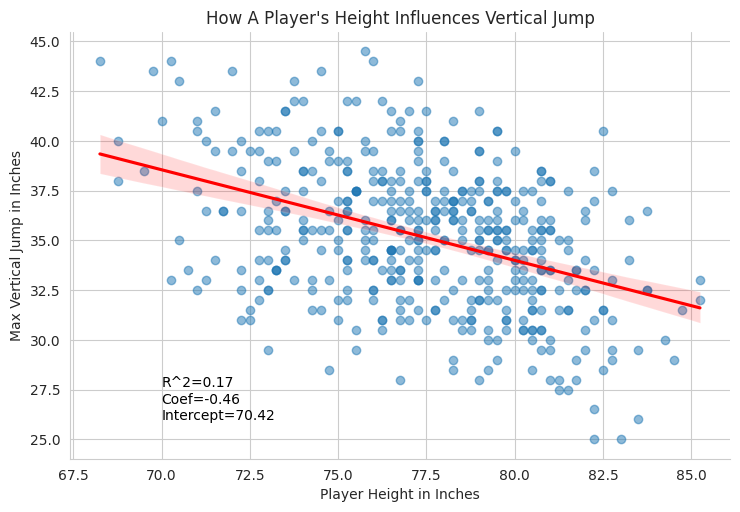

In [12]:
# Visualize how height relates to max vertical jump

sns.lmplot(
    data=df,
    x='Height (No Shoes)',
    y='Vertical (Max)',
    height=5,
    aspect=1.5,
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'}
)

plt.xlabel('Player Height in Inches')
plt.ylabel('Max Vertical Jump in Inches')
plt.title("How A Player's Height Influences Vertical Jump")
plt.text(
    70, 26,
    f"R^2={r2_height:.2f}\nCoef={coef_height_simple:.2f}\nIntercept={intercept_height:.2f}",
    fontsize=10,
    color='black'
)
plt.savefig('output/figures/height_vs_vertical.png', bbox_inches='tight')
plt.show()

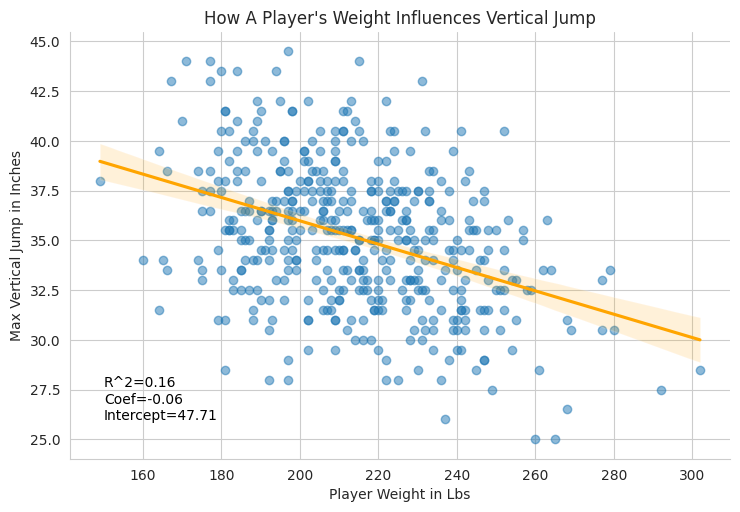

In [13]:
# Visualize how weight relates to max vertical jump

sns.lmplot(
    data=df,
    x='Weight',
    y='Vertical (Max)',
    height=5,
    aspect=1.5,
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'orange'}
)

plt.xlabel('Player Weight in Lbs')
plt.ylabel('Max Vertical Jump in Inches')
plt.title("How A Player's Weight Influences Vertical Jump")
plt.text(
    150, 26,
    f"R^2={r2_weight:.2f}\nCoef={coef_weight_simple:.2f}\nIntercept={intercept_weight:.2f}",
    fontsize=10,
    color='black'
)
plt.savefig('output/figures/weight_vs_vertical.png', bbox_inches='tight')
plt.show()

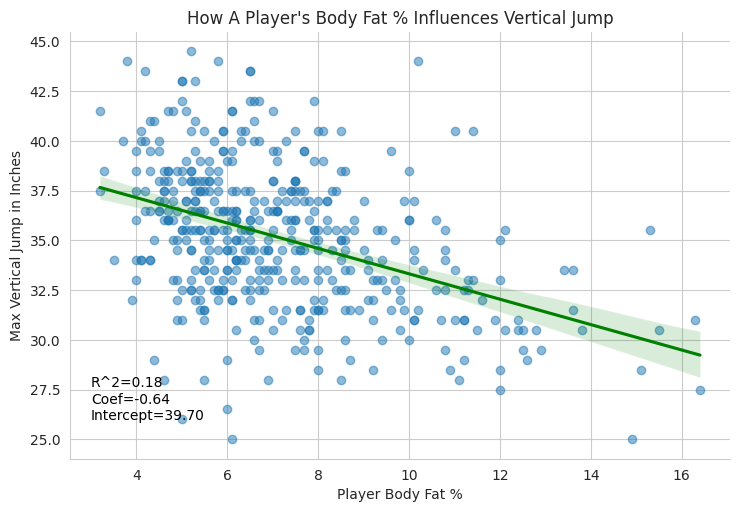

In [14]:
# Visualizing how body fat relates to max vertical jump

sns.lmplot(
    data=df,
    x='Body Fat',
    y='Vertical (Max)',
    height=5,
    aspect=1.5,
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'green'}
)

plt.xlabel('Player Body Fat %')
plt.ylabel('Max Vertical Jump in Inches')
plt.title("How A Player's Body Fat % Influences Vertical Jump")
plt.text(
    3, 26,
    f"R^2={r2_bodyfat:.2f}\nCoef={coef_bodyfat_simple:.2f}\nIntercept={intercept_bodyfat:.2f}",
    fontsize=10,
    color='black'
)
plt.savefig('output/figures/bodyfat_vs_vertical.png', bbox_inches='tight')
plt.show()

In [15]:
# Creating a draft-analysis subset
# Keep players who have an actual draft position recorded

draft_df = df.dropna(subset=['Draft pick']).copy()

print("Sample size for draft analysis:", len(draft_df))
draft_df[['Player', 'Vertical (Max)', 'Draft pick']].head()

Sample size for draft analysis: 332


,Player,Vertical (Max),Draft pick
0,Blake Griffin,35.5,1.0
1,Terrence Williams,37.0,11.0
2,Gerald Henderson,35.0,12.0
3,Tyler Hansbrough,34.0,13.0
4,Earl Clark,33.0,14.0


In [16]:
# Testing whether raw max vertical jump is associated with draft position

pearson_raw_r, pearson_raw_p = pearsonr(draft_df['Vertical (Max)'], draft_df['Draft pick'])
spearman_raw_rho, spearman_raw_p = spearmanr(draft_df['Vertical (Max)'], draft_df['Draft pick'])

print("RAW Vertical vs Draft Position")
print(f"Pearson r = {pearson_raw_r:.4f}, p-value = {pearson_raw_p:.4f}")
print(f"Spearman rho = {spearman_raw_rho:.4f}, p-value = {spearman_raw_p:.4f}")

RAW Vertical vs Draft Position
Pearson r = -0.0385, p-value = 0.4839
Spearman rho = -0.0622, p-value = 0.2585


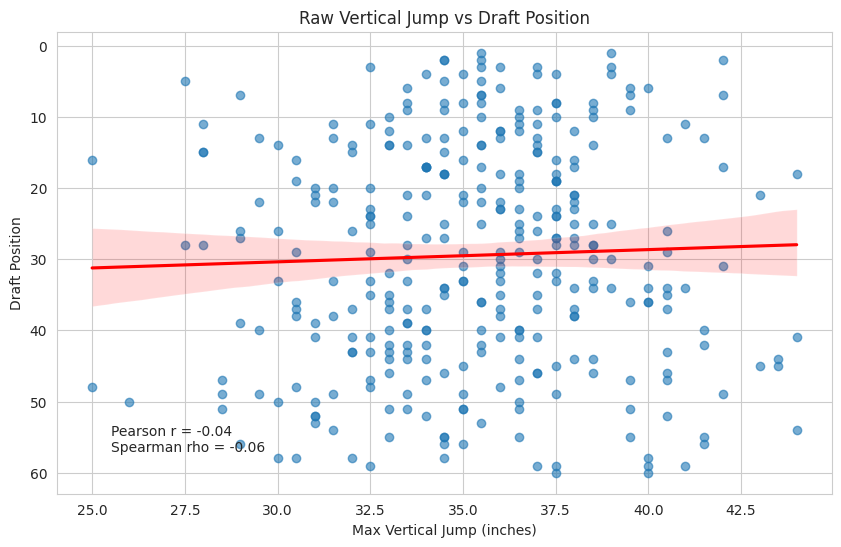

In [17]:
# Visualize the relationship between raw vertical jump and draft position
# Lower draft pick numbers are better which means a inverted the y-axis

plt.figure(figsize=(10, 6))

sns.regplot(
    data=draft_df,
    x='Vertical (Max)',
    y='Draft pick',
    scatter_kws={'alpha': 0.6},
    line_kws={'color': 'red'}
)

plt.gca().invert_yaxis()
plt.xlabel('Max Vertical Jump (inches)')
plt.ylabel('Draft Position')
plt.title('Raw Vertical Jump vs Draft Position')

plt.text(
    draft_df['Vertical (Max)'].min() + 0.5,
    draft_df['Draft pick'].max() - 3,
    f"Pearson r = {pearson_raw_r:.2f}\nSpearman rho = {spearman_raw_rho:.2f}",
    fontsize=10
)

plt.savefig('output/figures/raw_vertical_vs_draft.png', bbox_inches='tight')
plt.show()

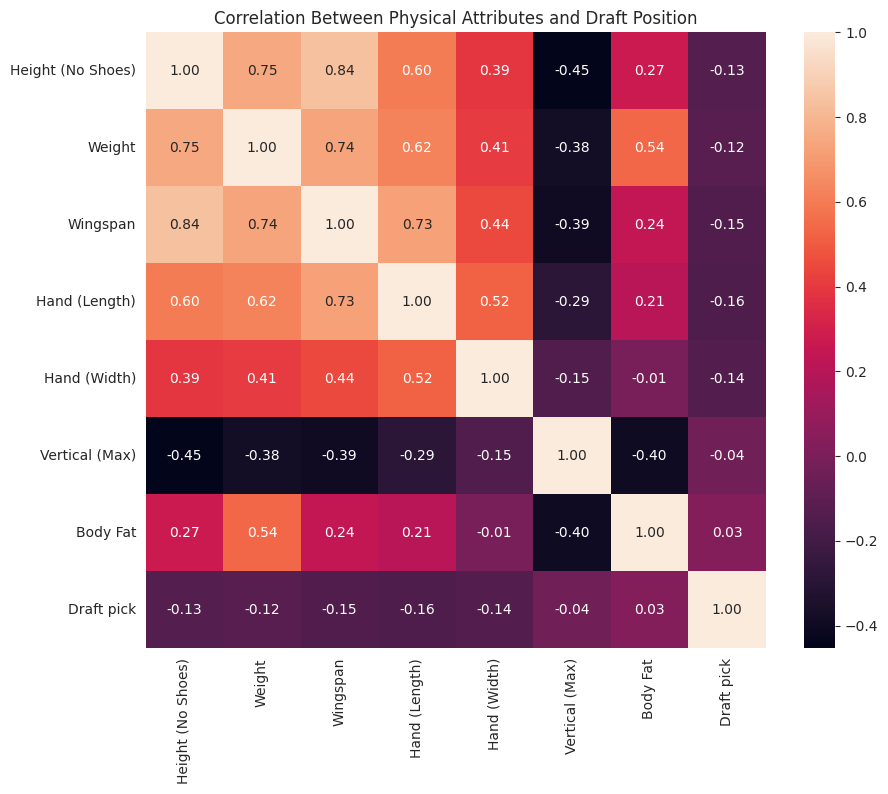

In [18]:
# Show broader correlations between physical traits and draft position

corr_matrix = draft_df[[
    'Height (No Shoes)',
    'Weight',
    'Wingspan',
    'Hand (Length)',
    'Hand (Width)',
    'Vertical (Max)',
    'Body Fat',
    'Draft pick'
]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f')
plt.title('Correlation Between Physical Attributes and Draft Position')
plt.savefig('output/figures/physical_traits_draft_heatmap.png', bbox_inches='tight')
plt.show()

In [19]:
# Standardize raw vertical jump performance across players

draft_df['vertical_zscore'] = (
    (draft_df['Vertical (Max)'] - np.mean(draft_df['Vertical (Max)']))
    / np.std(draft_df['Vertical (Max)'])
)

draft_df[['Player', 'Vertical (Max)', 'vertical_zscore']].head()

,Player,Vertical (Max),vertical_zscore
0,Blake Griffin,35.5,0.039137
1,Terrence Williams,37.0,0.462833
2,Gerald Henderson,35.0,-0.102096
3,Tyler Hansbrough,34.0,-0.384560
4,Earl Clark,33.0,-0.667024


In [20]:
# Predict what each player's vertical jump should be based on height, weight, and body fat
# Then compute the residual: actual - predicted
# This captures how much better or worse a player jumped than expected for his size/body composition

predicted_vertical = model.predict(draft_df[['Height (No Shoes)', 'Weight', 'Body Fat']])
residual_vertical = draft_df['Vertical (Max)'] - predicted_vertical

# Standardize the residual into a z-score
draft_df['size_adjusted_vertical'] = (
    (residual_vertical - np.mean(residual_vertical))
    / np.std(residual_vertical)
)

draft_df[['Player', 'Vertical (Max)', 'Draft pick', 'size_adjusted_vertical']].head()

,Player,Vertical (Max),Draft pick,size_adjusted_vertical
0,Blake Griffin,35.5,1.0,0.546436
1,Terrence Williams,37.0,11.0,0.118107
2,Gerald Henderson,35.0,12.0,-0.837325
3,Tyler Hansbrough,34.0,13.0,0.122808
4,Earl Clark,33.0,14.0,-0.773886


In [21]:
# Test whether size-adjusted explosiveness is associated with draft position

pearson_adj_r, pearson_adj_p = pearsonr(draft_df['size_adjusted_vertical'], draft_df['Draft pick'])
spearman_adj_rho, spearman_adj_p = spearmanr(draft_df['size_adjusted_vertical'], draft_df['Draft pick'])

print("SIZE-ADJUSTED VERTICAL vs Draft Position")
print(f"Pearson r = {pearson_adj_r:.4f}, p-value = {pearson_adj_p:.4f}")
print(f"Spearman rho = {spearman_adj_rho:.4f}, p-value = {spearman_adj_p:.4f}")

SIZE-ADJUSTED VERTICAL vs Draft Position
Pearson r = -0.0809, p-value = 0.1413
Spearman rho = -0.0919, p-value = 0.0946


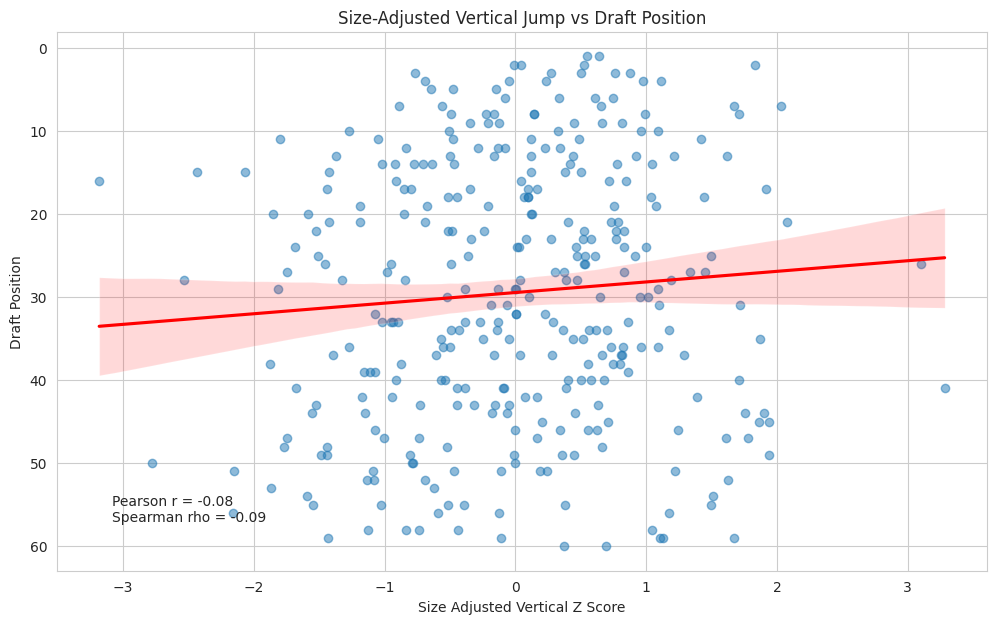

In [22]:
# Visualize whether adjusted explosiveness is more informative than raw vertical jump

plt.figure(figsize=(12, 7))

sns.regplot(
    data=draft_df,
    x='size_adjusted_vertical',
    y='Draft pick',
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'}
)

plt.gca().invert_yaxis()
plt.xlabel('Size Adjusted Vertical Z Score')
plt.ylabel('Draft Position')
plt.title('Size-Adjusted Vertical Jump vs Draft Position')

plt.text(
    draft_df['size_adjusted_vertical'].min() + 0.1,
    draft_df['Draft pick'].max() - 3,
    f"Pearson r = {pearson_adj_r:.2f}\nSpearman rho = {spearman_adj_rho:.2f}",
    fontsize=10
)

plt.savefig('output/figures/size_adjusted_vertical_vs_draft.png', bbox_inches='tight')
plt.show()

In [23]:
# Identify players who are unusually high or low relative to expected vertical jump

high_jumpers = draft_df[draft_df['size_adjusted_vertical'] > 1.5]
low_jumpers = draft_df[draft_df['size_adjusted_vertical'] < -1.5]

outliers = pd.concat([high_jumpers, low_jumpers])

print("Number of extreme outliers:", len(outliers))
outliers[['Player', 'Vertical (Max)', 'Draft pick', 'size_adjusted_vertical']].sort_values(
    by='size_adjusted_vertical',
    ascending=False
).head(20)

Number of extreme outliers: 46


,Player,Vertical (Max),Draft pick,size_adjusted_vertical
359,Pat Connaughton,44.0,41.0,3.281921
168,Miles Plumlee,40.5,26.0,3.098460
345,Justin Anderson,43.0,21.0,2.075596
198,Harrison Barnes,39.5,7.0,2.027256
134,Josh Selby,42.0,49.0,1.941155
423,Demetrius Jackson,43.5,45.0,1.936875
105,Iman Shumpert,42.0,17.0,1.917967
299,Markel Brown,43.5,44.0,1.902431
233,Glen Rice,40.5,35.0,1.872979
363,Marcus Thornton,43.0,45.0,1.864641


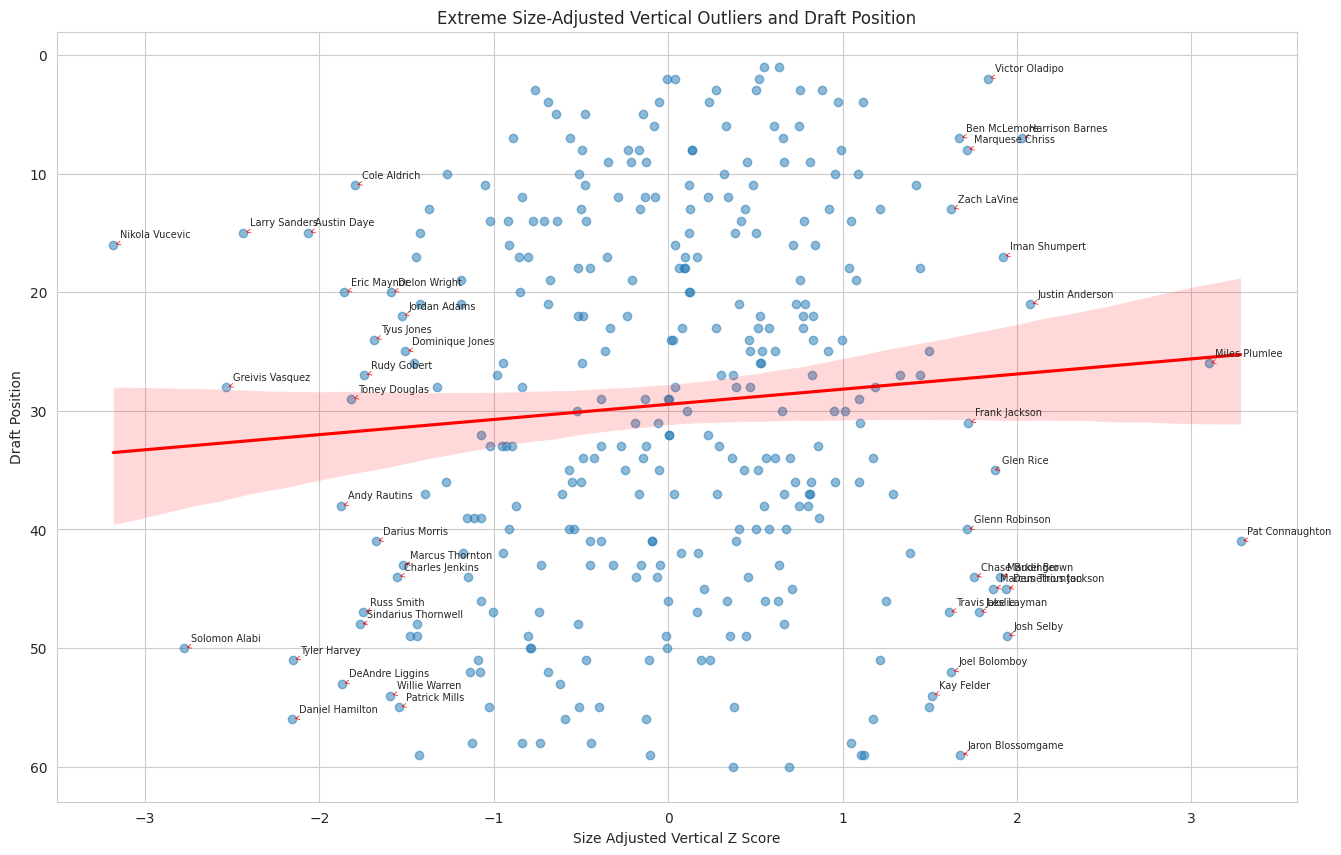

In [24]:
# Visualize extreme positive and negative adjusted jumpers against draft position

plt.figure(figsize=(16, 10))

sns.regplot(
    data=draft_df,
    x='size_adjusted_vertical',
    y='Draft pick',
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'}
)

for _, row in outliers.iterrows():
    plt.annotate(
        row['Player'],
        xy=(row['size_adjusted_vertical'], row['Draft pick']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=7,
        arrowprops=dict(arrowstyle='->', color='red', lw=0.5)
    )

plt.gca().invert_yaxis()
plt.xlabel('Size Adjusted Vertical Z Score')
plt.ylabel('Draft Position')
plt.title('Extreme Size-Adjusted Vertical Outliers and Draft Position')
plt.savefig('output/figures/annotated_outliers_draft_position.png', bbox_inches='tight')
plt.show()

In [25]:
# Select the top 10 and bottom 10 players by size-adjusted vertical score

top_10 = draft_df.nlargest(10, 'size_adjusted_vertical')
bottom_10 = draft_df.nsmallest(10, 'size_adjusted_vertical')

extreme_outliers = pd.concat([top_10, bottom_10])

extreme_outliers[['Player', 'Draft pick', 'size_adjusted_vertical']].sort_values(
    by='size_adjusted_vertical',
    ascending=False
)

,Player,Draft pick,size_adjusted_vertical
359,Pat Connaughton,41.0,3.281921
168,Miles Plumlee,26.0,3.098460
345,Justin Anderson,21.0,2.075596
198,Harrison Barnes,7.0,2.027256
134,Josh Selby,49.0,1.941155
423,Demetrius Jackson,45.0,1.936875
105,Iman Shumpert,17.0,1.917967
299,Markel Brown,44.0,1.902431
233,Glen Rice,35.0,1.872979
363,Marcus Thornton,45.0,1.864641


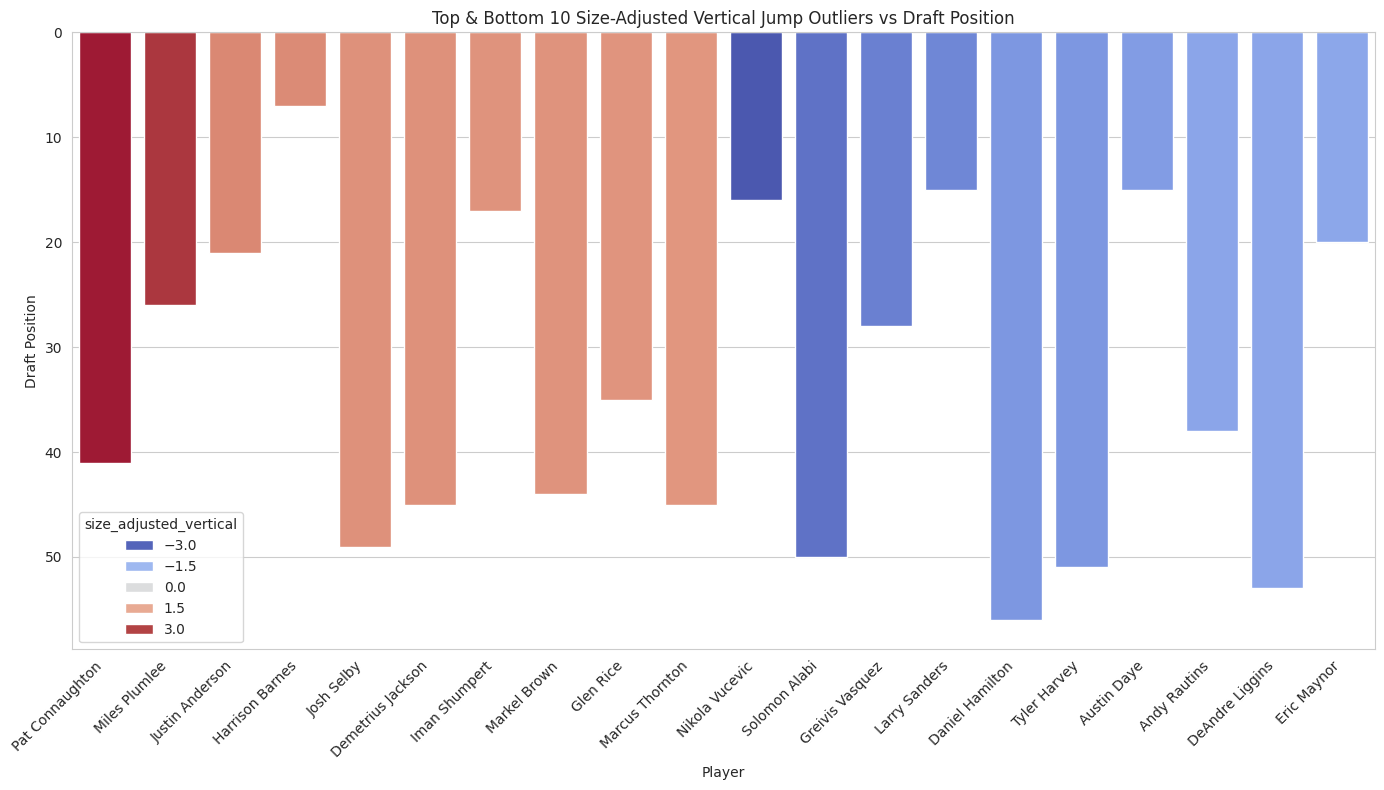

In [26]:
# Compare the most extreme positive and negative adjusted jumpers and where they were drafted

plt.figure(figsize=(14, 8))

sns.barplot(
    data=extreme_outliers,
    x='Player',
    y='Draft pick',
    hue='size_adjusted_vertical',
    palette='coolwarm'
)

plt.xlabel('Player')
plt.ylabel('Draft Position')
plt.title('Top & Bottom 10 Size-Adjusted Vertical Jump Outliers vs Draft Position')
plt.xticks(rotation=45, ha='right')
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig('output/figures/top_bottom_outliers_barplot.png', bbox_inches='tight')
plt.show()

In [27]:
# Group players into interpretable tiers based on size-adjusted vertical score

draft_df['jump_group'] = pd.cut(
    draft_df['size_adjusted_vertical'],
    bins=[-np.inf, -1, 0, 1, np.inf],
    labels=['Well Below Average', 'Below Average', 'Above Average', 'Elite']
)

draft_df[['Player', 'size_adjusted_vertical', 'jump_group']].head()

,Player,size_adjusted_vertical,jump_group
0,Blake Griffin,0.546436,Above Average
1,Terrence Williams,0.118107,Above Average
2,Gerald Henderson,-0.837325,Below Average
3,Tyler Hansbrough,0.122808,Above Average
4,Earl Clark,-0.773886,Below Average


<Figure size 1000x600 with 0 Axes>

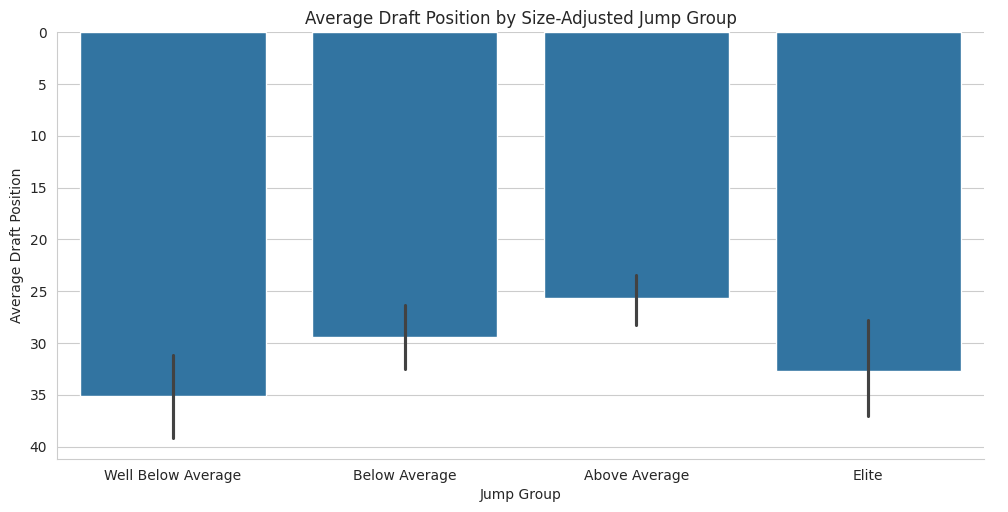

In [28]:
# Compare the average draft position for each adjusted-jump tier

plt.figure(figsize=(10, 6))

sns.catplot(
    data=draft_df,
    x='jump_group',
    y='Draft pick',
    kind='bar',
    height=5,
    aspect=2
)

plt.gca().invert_yaxis()
plt.title('Average Draft Position by Size-Adjusted Jump Group')
plt.xlabel('Jump Group')
plt.ylabel('Average Draft Position')

plt.savefig('output/figures/draft_position_by_jump_group.png', bbox_inches='tight')
plt.show()

In [29]:
# Numerical summary of average draft position by jump group

group_summary = draft_df.groupby('jump_group', observed=False)['Draft pick'].agg(['count', 'mean', 'median']).reset_index()
group_summary

,jump_group,count,mean,median
0,Well Below Average,55,35.163636,38.0
1,Below Average,105,29.390476,31.0
2,Above Average,124,25.709677,25.0
3,Elite,48,32.729167,32.5


In [32]:
# Compute a 95% confidence interval for a Pearson correlation using Fisher z-transform

def correlation_ci(r, n, alpha=0.05):
    z = np.arctanh(r)
    se = 1 / np.sqrt(n - 3)
    z_critical = 1.96
    lower_z = z - z_critical * se
    upper_z = z + z_critical * se
    lower_r = np.tanh(lower_z)
    upper_r = np.tanh(upper_z)
    return lower_r, upper_r

In [33]:
# confidence intervals to the draft-position correlation results

raw_ci = correlation_ci(pearson_raw_r, len(draft_df))
adj_ci = correlation_ci(pearson_adj_r, len(draft_df))

print("95% CI for RAW Vertical vs Draft Position Pearson r:", raw_ci)
print("95% CI for SIZE-ADJUSTED Vertical vs Draft Position Pearson r:", adj_ci)

95% CI for RAW Vertical vs Draft Position Pearson r: (np.float64(-0.14558524880525772), np.float64(0.06937786797226421))
95% CI for SIZE-ADJUSTED Vertical vs Draft Position Pearson r: (np.float64(-0.18692012266220667), np.float64(0.026966184536333804))


In [34]:
# Key results into one summary table

results_summary = pd.DataFrame({
    'Analysis': [
        'Height vs Vertical',
        'Weight vs Vertical',
        'Body Fat vs Vertical',
        'Raw Vertical vs Draft Position',
        'Size-Adjusted Vertical vs Draft Position'
    ],
    'Pearson / Correlation': [
        height_corr,
        weight_corr,
        bodyfat_corr,
        pearson_raw_r,
        pearson_adj_r
    ],
    'P-value': [
        np.nan,
        np.nan,
        np.nan,
        pearson_raw_p,
        pearson_adj_p
    ]
})

results_summary

,Analysis,Pearson / Correlation,P-value
0,Height vs Vertical,-0.416080,NaN
1,Weight vs Vertical,-0.398728,NaN
2,Body Fat vs Vertical,-0.422684,NaN
3,Raw Vertical vs Draft Position,-0.038550,0.483915
4,Size-Adjusted Vertical vs Draft Position,-0.080908,0.141272


In [35]:
# High-level interpretation of the project

print("PROJECT TAKEAWAYS")
print("- Height, weight, and body fat are all negatively related to max vertical jump.")
print("- The multiple regression model estimates how these physical traits jointly relate to vertical performance.")
print("- Raw vertical jump may show little or only weak association with draft position.")
print("- Size-adjusted vertical jump tests whether outperforming expected explosiveness for one's size/body composition matters more.")
print("- This helps distinguish raw athletic output from relative athletic advantage.")

PROJECT TAKEAWAYS
- Height, weight, and body fat are all negatively related to max vertical jump.
- The multiple regression model estimates how these physical traits jointly relate to vertical performance.
- Raw vertical jump may show little or only weak association with draft position.
- Size-adjusted vertical jump tests whether outperforming expected explosiveness for one's size/body composition matters more.
- This helps distinguish raw athletic output from relative athletic advantage.
